# Inference & Comparison (Base SDXL vs. Naruto-Style Fine-Tune)

1. Loads the original `stabilityai/stable-diffusion-xl-base-1.0` and generates the three
   test prompts.
2. Loads the same base model plus the fine-tuned LoRA weights from `train.ipynb`, and
   generates the identical three prompts with the same seeds.

In [1]:
!pip install -q -U pip wheel
!pip install -q "setuptools<82"

!pip install -q -U \
    "diffusers>=0.31.0" \
    "transformers>=4.44,<5.0" \
    "accelerate>=0.34" \
    "peft>=0.13" \
    "bitsandbytes>=0.43" \
    "datasets>=2.21" \
    "safetensors>=0.4.5" \
    "huggingface_hub>=0.24" \
    "DeepCache>=0.1.1" \
    "torchmetrics[image]>=1.4.1" \
    "torchmetrics[multimodal]>=1.4.1" \
    "torchao>=0.16.0" \
    pandas

!pip install -q -U xformers || echo "xformers install failed -- continuing without it."

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [12]:
import shutil
shutil.unpack_archive("/content/full_runs.zip", "/content/")

In [ ]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
import gc
import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusers import StableDiffusionXLPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

BASE_MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"

# Path to the best checkpoint saved by train.ipynb. 
LORA_PATH = "full_runs/DoRA_B_r16_α32"

TEST_PROMPTS = [
    "Naruto Uzumaki eating ramen",
    "Bill Gates in Naruto style",
    "A boy with blue eyes in Naruto style",
]
SEED = 42
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 7.0

def reset_memory():
    gc.collect(); torch.cuda.empty_cache()


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


device: cuda


## 1. Base SDXL — no fine-tuning

In [5]:
base_pipe = StableDiffusionXLPipeline.from_pretrained(
    BASE_MODEL_ID, torch_dtype=torch.float16, variant="fp16", use_safetensors=True,
).to(device)
base_pipe.set_progress_bar_config(disable=True)

base_images = []
for prompt in TEST_PROMPTS:
    gen = torch.Generator(device=device).manual_seed(SEED)
    image = base_pipe(prompt, num_inference_steps=NUM_INFERENCE_STEPS,
                       guidance_scale=GUIDANCE_SCALE, generator=gen).images[0]
    base_images.append(image)
    print(f"generated (base): {prompt!r}")

del base_pipe
reset_memory()


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

...

generated (base): 'Naruto Uzumaki eating ramen'


There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


generated (base): 'Bill Gates in Naruto style'


There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


generated (base): 'A boy with blue eyes in Naruto style'


## 2. Fine-tuned — base SDXL + trained LoRA weights

In [ ]:
!pip install -q huggingface_hub

In [9]:
from huggingface_hub import notebook_login

notebook_login()

In [20]:
ft_pipe = StableDiffusionXLPipeline.from_pretrained(
    BASE_MODEL_ID, torch_dtype=torch.float16, variant="fp16", use_safetensors=True,
).to(device)
ft_pipe.load_lora_weights(LORA_PATH)
ft_pipe.set_progress_bar_config(disable=True)

ft_images = []
for prompt in TEST_PROMPTS:
    gen = torch.Generator(device=device).manual_seed(SEED)
    image = ft_pipe(prompt, num_inference_steps=NUM_INFERENCE_STEPS,
                     guidance_scale=GUIDANCE_SCALE, generator=gen).images[0]
    ft_images.append(image)
    print(f"generated (fine-tuned): {prompt!r}")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. Fo

generated (fine-tuned): 'Naruto Uzumaki eating ramen'


There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


generated (fine-tuned): 'Bill Gates in Naruto style'


There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


generated (fine-tuned): 'A boy with blue eyes in Naruto style'


## 3. Side-by-side comparison

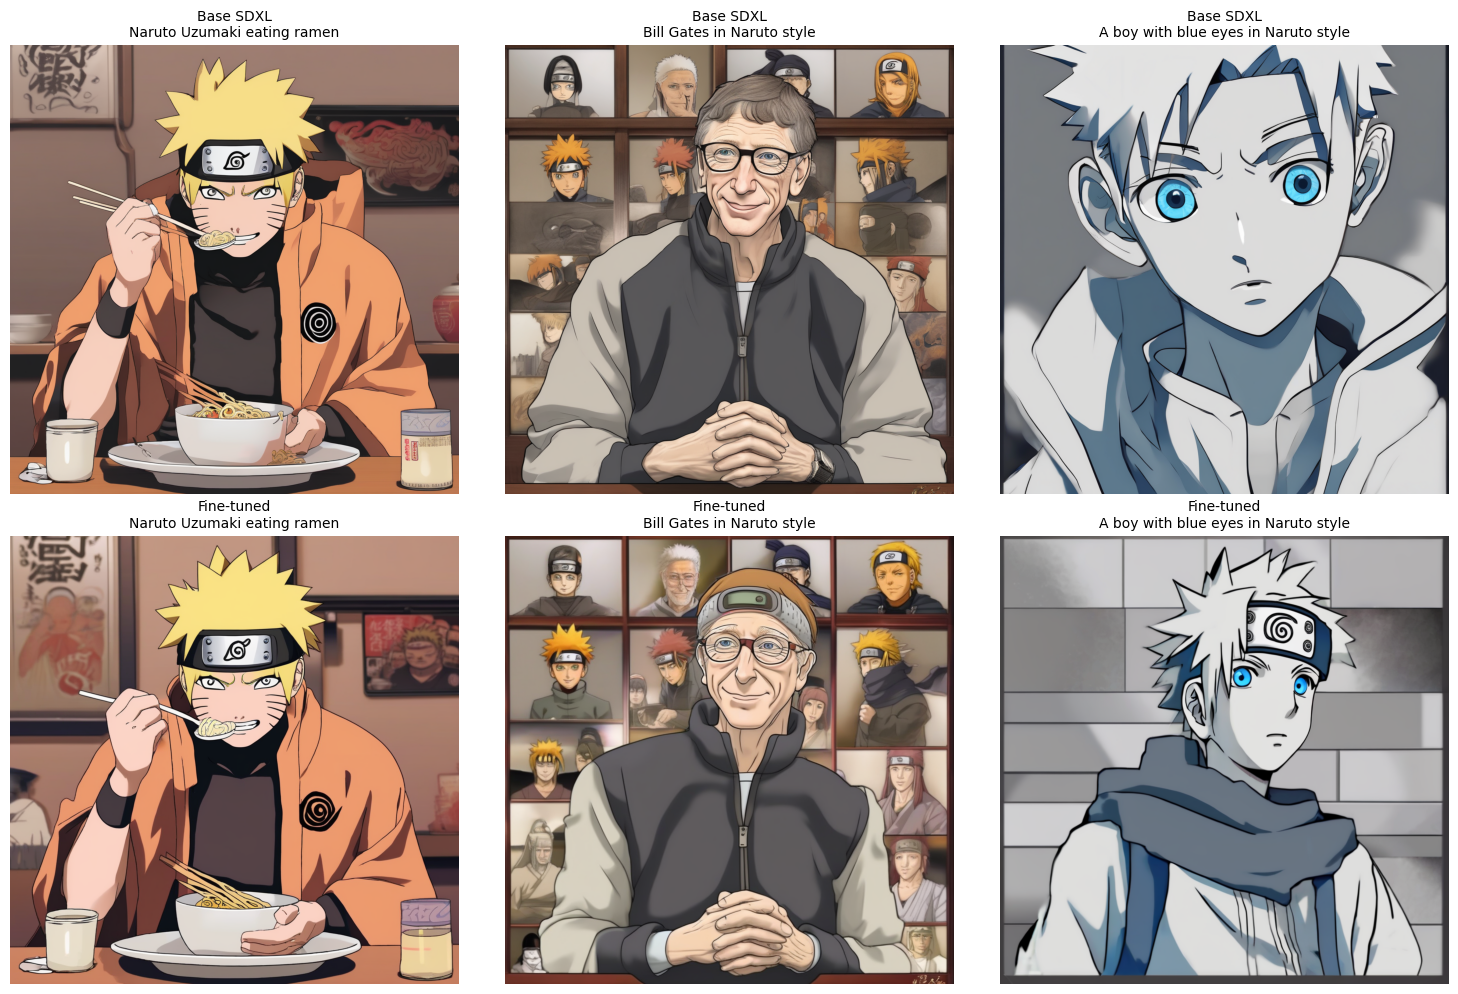

In [21]:
n = len(TEST_PROMPTS)
fig, axes = plt.subplots(2, n, figsize=(5 * n, 10))
for i, prompt in enumerate(TEST_PROMPTS):
    axes[0, i].imshow(base_images[i])
    axes[0, i].set_title(f"Base SDXL\n{prompt}", fontsize=10)
    axes[0, i].axis("off")
    axes[1, i].imshow(ft_images[i])
    axes[1, i].set_title(f"Fine-tuned\n{prompt}", fontsize=10)
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig("comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
import os
os.makedirs("outputs/base", exist_ok=True)
os.makedirs("outputs/finetuned", exist_ok=True)
for i, prompt in enumerate(TEST_PROMPTS):
    slug = prompt.lower().replace(" ", "_")[:40]
    base_images[i].save(f"outputs/base/{slug}.png")
    ft_images[i].save(f"outputs/finetuned/{slug}.png")
print("Saved individual images to outputs/base/ and outputs/finetuned/")


Saved individual images to outputs/base/ and outputs/finetuned/
